In [72]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data cleaning

In [73]:
df = pd.read_csv('../data/raw/Day-ahead_prices_202601010000_202606010000_Hour.csv',delimiter=';')

# Start date' strings into proper datetime objects
df['Start date'] = pd.to_datetime(df['Start date'], format='%b %d, %Y %I:%M %p')
df = df.rename(columns={'Start date': 'Time series [h]'}) 

# Rename columns to remove any hidden odd characters
df.columns = df.columns.str.replace('∅', '')
df.columns = df.columns.str.replace(' Calculated resolutions', '', regex=False)

df = df.drop(columns=['End date']) # remove column
df = df.drop(columns=['DE/AT/LU [€/MWh]']) # remove column

#df.describe()
print(df.isna().sum())
#df.info()

df_germany = df.iloc[:,:2]

# Drop the specific date (2026-03-29) DST
day_counts = df_germany.groupby(df_germany['Time series [h]'].dt.date).size()
incomplete_days = day_counts[day_counts != 24].index
df_germany = df_germany[~df_germany['Time series [h]'].dt.date.isin(incomplete_days)]

df_germany.to_csv('../data/processed/Germany_Day-ahead_prices_202601010000_202606010000_Hour.csv', encoding='utf-8', index=False, header=True)

Time series [h]               0
Germany/Luxembourg [€/MWh]    0
 DE/LU neighbours [€/MWh]     0
Belgium [€/MWh]               0
Denmark 1 [€/MWh]             0
Denmark 2 [€/MWh]             0
France [€/MWh]                0
Netherlands [€/MWh]           0
Norway 2 [€/MWh]              0
Austria [€/MWh]               0
Poland [€/MWh]                0
Sweden 4 [€/MWh]              0
Switzerland [€/MWh]           0
Czech Republic [€/MWh]        0
Northern Italy [€/MWh]        0
Slovenia [€/MWh]              0
Hungary [€/MWh]               0
dtype: int64


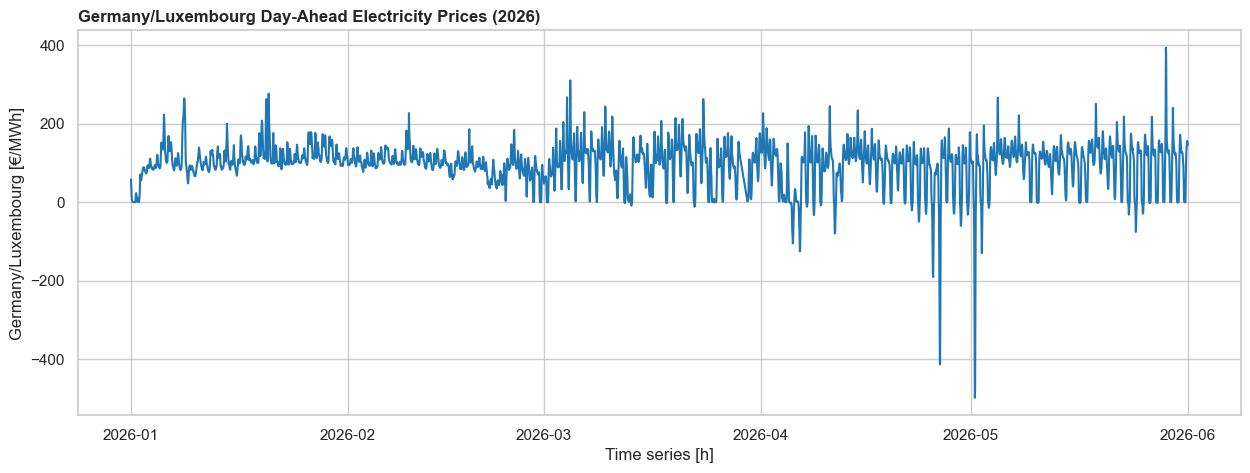

In [74]:
# Plotting
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 5))
sns.lineplot(data=df_germany, x='Time series [h]', y=df_germany.columns[1], color='#1f77b4')

plt.title('Germany/Luxembourg Day-Ahead Electricity Prices (2026)', loc='left', fontweight='bold')
plt.show()

## Missing time series check

In [75]:
# Check for missing data patterns
df_germany['date_hour'] = df_germany['Time series [h]'].dt.strftime('%Y-%m-%d %H:00')
hourly_gaps = df_germany['date_hour'].isna().sum()

# Verify we have complete days
days_with_24_hours = df_germany.groupby(df_germany['Time series [h]'].dt.date).size()
incomplete_days = days_with_24_hours[days_with_24_hours != 24]
print(f"Days with incomplete hourly data: {len(incomplete_days)}")
if len(incomplete_days) > 0:
    print(incomplete_days)

Days with incomplete hourly data: 0


## Price spread

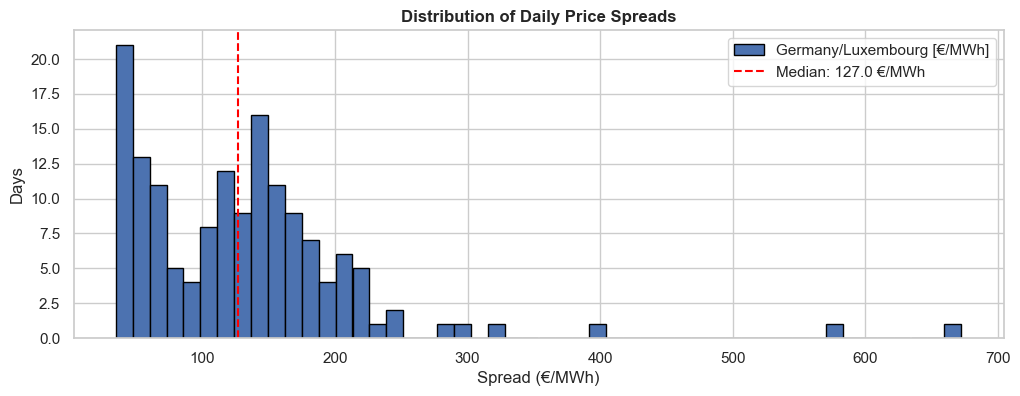

Days with spread > 100€: 95
Days with spread > 200€: 20


In [76]:
# Daily max spread for Germany
daily_max = df_germany.groupby(df_germany['Time series [h]'].dt.date)['Germany/Luxembourg [€/MWh]'].max()
daily_min = df_germany.groupby(df_germany['Time series [h]'].dt.date)['Germany/Luxembourg [€/MWh]'].min()
daily_spread = daily_max - daily_min

# Plot spreads
plt.figure(figsize=(12, 4))
daily_spread.plot(kind='hist', bins=50, edgecolor='black')
plt.title('Distribution of Daily Price Spreads', fontweight='bold')
plt.xlabel('Spread (€/MWh)')
plt.ylabel('Days')
plt.axvline(daily_spread.median(), color='red', linestyle='--', label=f'Median: {daily_spread.median():.1f} €/MWh')
plt.legend()
plt.show()

print(f"Days with spread > 100€: {(daily_spread > 100).sum()}")
print(f"Days with spread > 200€: {(daily_spread > 200).sum()}")

In [77]:
# Check if the high spreads come from extremely low prices or extremely high prices
daily_min = df_germany.groupby(df_germany['Time series [h]'].dt.date)['Germany/Luxembourg [€/MWh]'].min()
daily_max = df_germany.groupby(df_germany['Time series [h]'].dt.date)['Germany/Luxembourg [€/MWh]'].max()

# Identify what's driving the spread
negative_price_days = (daily_min < 0).sum()
very_high_price_days = (daily_max > 300).sum()
very_low_price_days = (daily_min < 50).sum()  # below €50 is cheap for Europe

print(f"Days with negative prices: {negative_price_days}")
print(f"Days with prices > 300 €/MWh: {very_high_price_days}")
print(f"Days with prices < 50 €/MWh: {very_low_price_days}")

# Calculate spread components
spread_from_lows = daily_max - daily_min.clip(upper=0)  # negative prices contribute
spread_from_highs = daily_max.clip(lower=300) - daily_min

print(f"\nSpread driven by negative prices: €{spread_from_lows.mean():.0f}")
print(f"Spread driven by extreme highs (>300): €{spread_from_highs.mean():.0f}")

Days with negative prices: 45
Days with prices > 300 €/MWh: 2
Days with prices < 50 €/MWh: 80

Spread driven by negative prices: €176
Spread driven by extreme highs (>300): €269


## Negative price

In [78]:
negative_prices = df_germany[df_germany['Germany/Luxembourg [€/MWh]'] < 0]
negative_by_hour = negative_prices.groupby(negative_prices['Time series [h]'].dt.hour).size()

print(f"Total negative price hours: {len(negative_prices)}")
print(f"Most common hour for negative prices: {negative_by_hour.idxmax()}:00")
print(f"Most negative price: {negative_prices['Germany/Luxembourg [€/MWh]'].min():.2f} €/MWh")

Total negative price hours: 239
Most common hour for negative prices: 13:00
Most negative price: -499.00 €/MWh


## Hourly price pattern

Highest price hours (average):
            mean        std
Hour                       
19    142.866133  37.327536
20    138.872933  45.244306
18    135.474400  41.421586


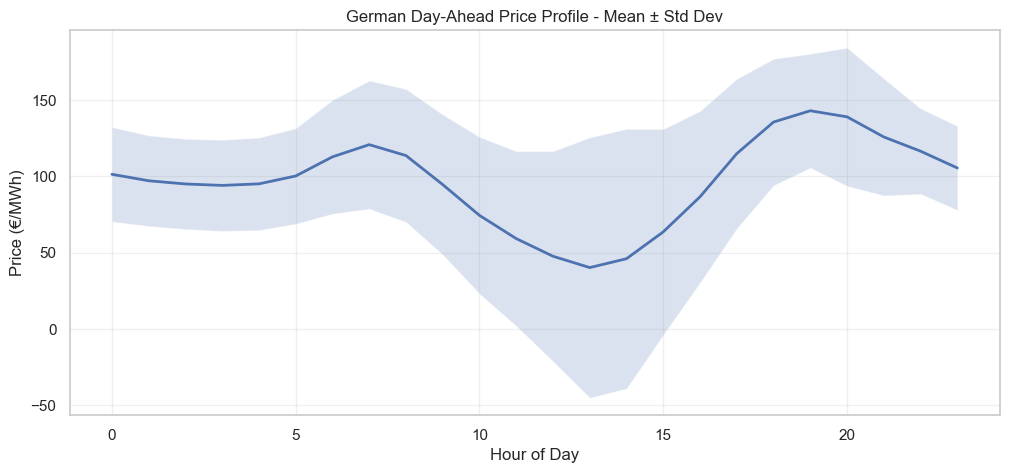

In [79]:
df_germany['Hour'] = df_germany['Time series [h]'].dt.hour
df_germany['Month'] = df_germany['Time series [h]'].dt.month

# Average price by hour
hourly_profile = df_germany.groupby('Hour')['Germany/Luxembourg [€/MWh]'].agg(['mean', 'std'])

# Peak hour identification
peak_hours = hourly_profile.nlargest(3, 'mean')
print("Highest price hours (average):")
print(peak_hours)

# Plot hourly profile
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_profile.index, hourly_profile['mean'], 'b-', linewidth=2)
ax.fill_between(hourly_profile.index, 
                hourly_profile['mean'] - hourly_profile['std'],
                hourly_profile['mean'] + hourly_profile['std'], 
                alpha=0.2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('German Day-Ahead Price Profile - Mean ± Std Dev')
ax.grid(True, alpha=0.3)
plt.show()